# Boyle's Law

In [ ]:
import matplotlib.pyplot as plt
from typing import Literal
from IPython.display import clear_output, display
import numpy as np

def make_graph(k_values: list, represent: Literal['p_to_v', 'v_to_p', 'p_to_inv_v']):
    """
    Boyle's Law (PV = K) with different representations.
    
    Parameters:
    - k_values: List of constant K values to plot
    - represent: Type of graph
        'p_to_v': Volume on X-axis, Pressure on Y-axis
        'v_to_p': Pressure on X-axis, Volume on Y-axis
        'p_to_inv_v': Pressure on X-axis, 1/Volume on Y-axis
    
    Returns:
    - Dictionary with original (unscaled) volume and pressure values for each K
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    plt.ion()
    
    max_k = max(k_values)
    
    ax.set_title(f"PV = K\n(K values: {', '.join(map(str, k_values))})", fontsize=14, fontweight='bold')
    
    if represent == 'p_to_v':
        ax.set_xlabel("Volume (V)", fontsize=12)
        ax.set_ylabel("Pressure (P)", fontsize=12)
    elif represent == 'v_to_p':
        ax.set_xlabel("Pressure (P)", fontsize=12)
        ax.set_ylabel("Volume (V)", fontsize=12)
    else: # p_to_inv_v
        ax.set_xlabel("1/Volume (1/V)", fontsize=12)
        ax.set_ylabel("Pressure (P)", fontsize=12)
    
    if represent == 'p_to_inv_v':
        ax.set_ylim(0, max_k * 1.1)
        ax.set_xlim(0, 1.1)
        ax.set_xticks(np.arange(0.0, 1.1, 0.1))
    else:
        ax.set_ylim(0, max_k * 1.1)
        ax.set_xlim(0, max_k * 1.1)
    
    ax.grid(True, alpha=0.6)
    
    results = {}
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(k_values)))
    
    for idx, k_single in enumerate(k_values):
        # unscaled data for return values
        pressure_original = []
        volume_original = []
        volume_inv = []
        
        x_data = []
        y_data = []
        
        # line for this specific k value
        graph = ax.plot([], [], label=f"K = {k_single}", color=colors[idx], linewidth=2)[0]
        
        # data points from P=1 to P=k
        for p in range(1, int(k_single) + 1):
            pressure_original.append(float(p))
            volume_original.append(k_single / p)
            volume_inv.append(p / k_single)
        
        # smooth spline curve for 100 points
        p_smooth = np.linspace(1, k_single, 100)
        v_smooth = k_single / p_smooth
        
        if represent == 'p_to_v':
            x_smooth = v_smooth
            y_smooth = p_smooth
        elif represent == 'v_to_p':
            x_smooth = p_smooth
            y_smooth = v_smooth
        else: # p_to_inv_v
            x_smooth = p_smooth / k_single  # 1/V = P/K
            y_smooth = p_smooth
        
        graph.set_xdata(x_smooth)
        graph.set_ydata(y_smooth)
        
        # markers
        for p in range(1, int(k_single) + 1):
            v = k_single / p
            
            if represent == 'p_to_v':
                ax.plot(v, p, 'o', color=colors[idx], markersize=6, markeredgecolor='black', markeredgewidth=0.5)
            elif represent == 'v_to_p':
                ax.plot(p, v, 'o', color=colors[idx], markersize=6, markeredgecolor='black', markeredgewidth=0.5)
            else: # p_to_inv_v
                ax.plot(p / k_single, p, 'o', color=colors[idx], markersize=6, markeredgecolor='black', markeredgewidth=0.5)
        
        # unscaled values
        results[k_single] = {
            'pressure': pressure_original,
            'volume': volume_original,
            'volume_inv': volume_inv
        }
        
        clear_output(wait=True)
        display(fig)
    
    ax.legend(fontsize=10, loc='best')
    clear_output(wait=True)
    display(fig)
    plt.ioff()
    
    return results

When **temperature** and the **amount of gas molecules** are **constant**, **Boyle's Law** states:

$$
P \propto \frac{1}{V} \quad \text{or equivalently} \quad PV = K
$$

Where:
- $P$ = pressure (e.g., in kPa)
- $V$ = volume (e.g., in liters)
- $K$ = a constant (determined by temperature and amount of gas)

When:
- $\uparrow$ V $\downarrow$ P (When volume increases, the pressure decreases)
- $\downarrow$ V $\uparrow$ P (When volume decreases, the pressure increases)

For an example:
If you **double** the volume ($V \to 2V$), pressure **halves** ($P \to P/2$).  
Similarly, if you **halve** the volume ($V \to V/2$), pressure **doubles** ($P \to 2P$).

Example with $K = 10$:
- If $V = 5$, $P = \frac{10}{5} = 2$
- If $V = 10$, $P = \frac{10}{10} = 1$

---

## P to V Graph

This graph shows a hyperbolic curve because pressure and volume are inversely related.

The curve is a hyperbola because every point $(P, V)$ satisfies $PV = K$. When volume increases, pressure decreases proportionally.

### Data Table

Let $k = 10$:

| Pressure (P) | Volume (k/P) | Explanation |
|--------------|--------------|-------------|
| 1.0          | 10.0         | V = 10/1.0  |
| 2.0          | 5.0          | V = 10/2.0  |
| 3.0          | 3.33         | V = 10/3.0  |
| 4.0          | 2.5          | V = 10/4.0  |
| 5.0          | 2.0          | V = 10/5.0  |
| 6.0          | 1.67         | V = 10/6.0  |
| 7.0          | 1.43         | V = 10/7.0  |
| 8.0          | 1.25         | V = 10/8.0  |
| 9.0          | 1.11         | V = 10/9.0  |
| 10.0         | 1.0          | V = 10/10.0 |

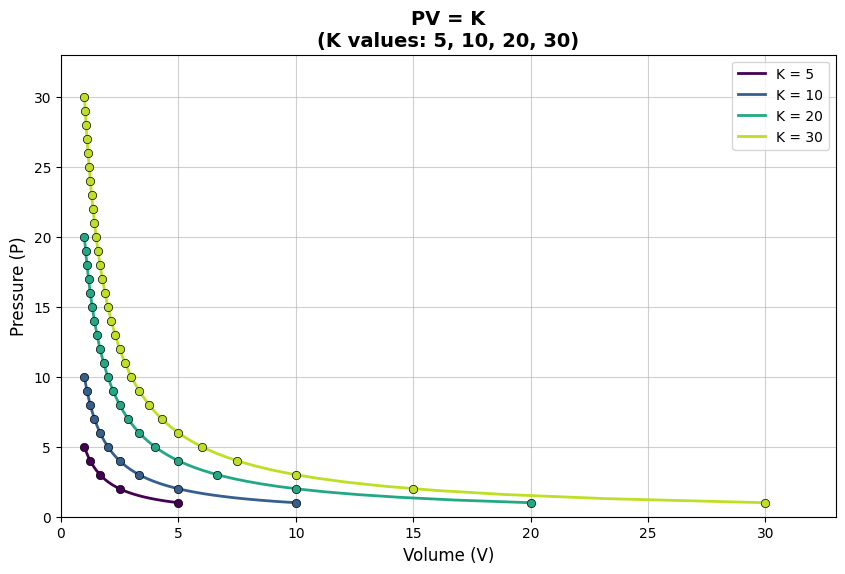

k: 5 
pressure: [1.0, 2.0, 3.0, 4.0, 5.0] 
volume: [5.0, 2.5, 1.67, 1.25, 1.0]
(showing only first 10 values!)
k: 10 
pressure: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0] 
volume: [10.0, 5.0, 3.33, 2.5, 2.0, 1.67, 1.43, 1.25, 1.11, 1.0]
(showing only first 10 values!)
k: 20 
pressure: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0] 
volume: [20.0, 10.0, 6.67, 5.0, 4.0, 3.33, 2.86, 2.5, 2.22, 2.0]
(showing only first 10 values!)
k: 30 
pressure: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0] 
volume: [30.0, 15.0, 10.0, 7.5, 6.0, 5.0, 4.29, 3.75, 3.33, 3.0]
(showing only first 10 values!)


In [ ]:
result = make_graph(k_values=[5, 10, 20, 30], represent='p_to_v')

for key, value in result.items():
    k = key
    volume = [round(value, 2) for value in value['volume'][:10]]
    pressure = [round(value, 2) for value in value['pressure'][:10]]

    print(f"k: {k} \npressure: {pressure} \nvolume: {volume}")
    print("(showing only first 10 values!)")
    print('=' * 35)

---

## V to P Graph

This graph also shows the same relationship but with axes swapped.

### Data Table

Let $k = 10$:

| Volume (V) | Pressure (k/V) | Explanation |
|------------|----------------|-------------|
| 1          | 10.0           | P = 10/1    |
| 2          | 5.0            | P = 10/2    |
| 3          | 3.33           | P = 10/3    |
| 4          | 2.5            | P = 10/4    |
| 5          | 2.0            | P = 10/5    |
| 6          | 1.67           | P = 10/6    |
| 7          | 1.43           | P = 10/7    |
| 8          | 1.25           | P = 10/8    |
| 9          | 1.11           | P = 10/9    |
| 10         | 1.0            | P = 10/10   |

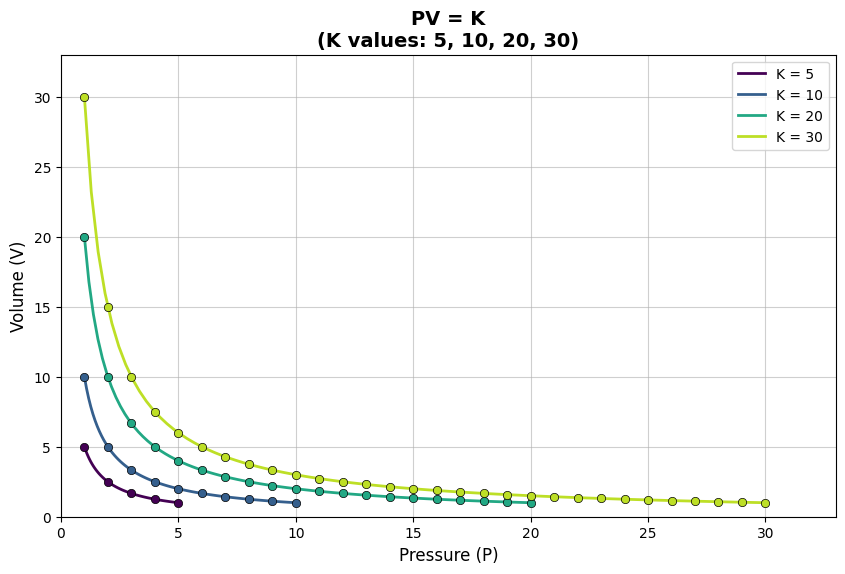

k: 5 
pressure: [1.0, 2.0, 3.0, 4.0, 5.0] 
volume: [5.0, 2.5, 1.67, 1.25, 1.0]
(showing only first 10 values!)
k: 10 
pressure: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0] 
volume: [10.0, 5.0, 3.33, 2.5, 2.0, 1.67, 1.43, 1.25, 1.11, 1.0]
(showing only first 10 values!)
k: 20 
pressure: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0] 
volume: [20.0, 10.0, 6.67, 5.0, 4.0, 3.33, 2.86, 2.5, 2.22, 2.0]
(showing only first 10 values!)
k: 30 
pressure: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0] 
volume: [30.0, 15.0, 10.0, 7.5, 6.0, 5.0, 4.29, 3.75, 3.33, 3.0]
(showing only first 10 values!)


In [ ]:
result = make_graph(k_values=[5, 10, 20, 30], represent='v_to_p')

for key, value in result.items():
    k = key
    volume = [round(value, 2) for value in value['volume'][:10]]
    pressure = [round(value, 2) for value in value['pressure'][:10]]

    print(f"k: {k} \npressure: {pressure} \nvolume: {volume}")
    print("(showing only first 10 values!)")
    print('=' * 35)

---

## P to 1/V Graph

This graph shows the relationship between pressure and the inverse of volume (1/V). This produces a **linear graph**.

### Mathematical Explanation

From Boyle's Law: $PV = k$

Rearranging: 

$P = \frac{k}{V}$ or $P = k \times \frac{1}{V}$

$V = \frac{k}{P}$

### Graphical Interpretation

**Option 1: Plotting $P$ versus $\frac{k}{V}$**

If we were to plot $P$ versus $\frac{k}{V}$, the slope would always be 1 (since $\frac{k}{V} = P$, giving us the linear relationship $y = x$). However, plotting it this way would be useless because we would simply be plotting $P$ against itself.

Here's why $\frac{k}{V} = P$:

$$
\frac{k}{V} = \frac{k}{\frac{k}{P}} = \frac{k}{1} \times \frac{P}{k} = P
$$

Since $\frac{k}{V}$ equals $P$, we would just be creating an identity line ($y = x$) that doesn't provide any meaningful insight into the relationship between pressure and volume.

**Option 2: Plotting $P$ versus $\frac{1}{V}$ (The Useful Graph)**

Alternatively, if we plot $P$ versus $\frac{1}{V}$, the slope would be $k$.

This follows the form $y = mx$, where:
- $y = P$ (pressure)
- $x = \frac{1}{V}$ (inverse volume)
- $m = k$ (the slope)

This graph is useful because it linearizes the inverse relationship, making it easy to determine the constant $k$ from the slope and verify Boyle's Law experimentally.

### Data Table

The table below shows the values of Pressure, Volume, and Inverse Volume (1/V) for different pressures when $k = 10$. 

When graphing $P$ versus $\frac{1}{V}$:
- Pressure ($P$) is plotted on the y-axis
- Inverse Volume ($\frac{1}{V}$) is plotted on the x-axis

Let $k = 10$:

| Pressure (P) | Volume (V = 10/P) | Inverse Volume (1/V) |
|--------------|-------------------|----------------------|
| **1.0**      | **10.00**         | **0.10**             |
| **2.0**      | **5.00**          | **0.20**             |
| 3.0          | 3.33              | 0.30                 |
| **4.0**      | **2.50**          | **0.40**             |
| 5.0          | 2.00              | 0.50                 |
| 6.0          | 1.67              | 0.60                 |
| 7.0          | 1.43              | 0.70                 |
| **8.0**      | **1.25**          | **0.80**             |
| 9.0          | 1.11              | 0.90                 |
| **10.0**     | **1.00**          | **1.00**             |

Note: When $k = 10$, we can verify that $\frac{1}{V} = \frac{P}{10}$, which confirms that $P = 10 \times \frac{1}{V}$, showing the linear relationship with slope $k = 10$.

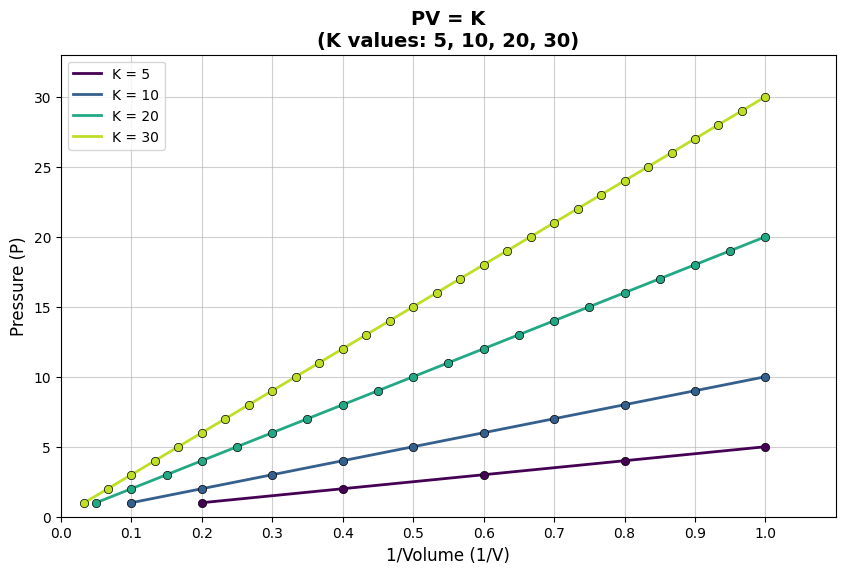

k: 5 
pressure: [1.0, 2.0, 3.0, 4.0, 5.0] 
volume_inv: [0.2, 0.4, 0.6, 0.8, 1.0]
(showing only first 10 values!)
k: 10 
pressure: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0] 
volume_inv: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
(showing only first 10 values!)
k: 20 
pressure: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0] 
volume_inv: [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
(showing only first 10 values!)
k: 30 
pressure: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0] 
volume_inv: [0.03, 0.07, 0.1, 0.13, 0.17, 0.2, 0.23, 0.27, 0.3, 0.33]
(showing only first 10 values!)


In [ ]:
result = make_graph(k_values=[5, 10, 20, 30], represent='p_to_inv_v')

for key, value in result.items():
    k = key
    volume_inv = [round(value, 2) for value in value['volume_inv'][:10]]
    pressure = [round(value, 2) for value in value['pressure'][:10]]

    print(f"k: {k} \npressure: {pressure} \nvolume_inv: {volume_inv}")
    print("(showing only first 10 values!)")
    print('=' * 35)